
# Semantic Bridging over Prolog Models

Este notebook executa, **somente com base nos arquivos Prolog** `entities.pl`, `triples.pl` e `rules.pl`, as três perguntas de competência:

1. **What other products the user could buy?**
2. **Which product categories should be prioritized for a discount?**
3. **Which two products would be the most suitable candidates for a bundle discount?**

O notebook foi escrito para usar **apenas predicados que existem de fato nos arquivos Prolog**.


In [1]:
# Instalação do SWI-Prolog e dependências
!apt-get update -qq
!apt-get install -y swi-prolog > /dev/null
!pip install -q pyswip pandas


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [2]:
import os
import pandas as pd
from pyswip import Prolog
from google.colab import drive

In [3]:
# Monta o Google Drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [4]:
# Ajuste este diretório se necessário
directory = "/content/drive/My Drive/KOA RecomSys/"

entities_path = os.path.join(directory, "entities.pl")
triples_path  = os.path.join(directory, "triples.pl")
rules_path    = os.path.join(directory, "rules.pl")

print("entities_path:", entities_path)
print("triples_path :", triples_path)
print("rules_path   :", rules_path)

for path in [entities_path, triples_path, rules_path]:
    print(path, "->", "OK" if os.path.exists(path) else "NOT FOUND")

if not all(os.path.exists(p) for p in [entities_path, triples_path, rules_path]):
    raise FileNotFoundError("Um ou mais arquivos Prolog não foram encontrados no diretório informado.")


entities_path: /content/drive/My Drive/KOA RecomSys/entities.pl
triples_path : /content/drive/My Drive/KOA RecomSys/triples.pl
rules_path   : /content/drive/My Drive/KOA RecomSys/rules.pl
/content/drive/My Drive/KOA RecomSys/entities.pl -> OK
/content/drive/My Drive/KOA RecomSys/triples.pl -> OK
/content/drive/My Drive/KOA RecomSys/rules.pl -> OK


In [5]:
# Carrega a base de conhecimento
prolog = Prolog()

def load_knowledge_base():
    global prolog
    prolog = Prolog()
    prolog.consult(entities_path.replace("\\", "/"))
    prolog.consult(triples_path.replace("\\", "/"))
    prolog.consult(rules_path.replace("\\", "/"))
    print("✅ Base de conhecimento carregada com sucesso.")

load_knowledge_base()


✅ Base de conhecimento carregada com sucesso.


In [6]:
# Verificação dos predicados que serão usados no notebook
predicates_to_check = [
    "product_name/2",
    "product_brand/2",
    "product_category/2",
    "same_brand/2",
    "same_category/2",
    "related_also_buy/2",
    "related_also_view/2",
    "unpack_relation/3",
    "user_intent_alignment/2",
    "semantic_recommendation/3",
    "explain_recommendation/3",
    "count_user_purchases_in_category/3",
    "count_user_also_buy_targets_in_category/3",
    "user_mentions_category/2",
    "prioritized_discount_category/7",
    "candidate_bundle_pair/2",
    "bundle_score/3",
    "bundle_explanation/3",
    "bundle_discount_candidate/6"
]

missing = []
for pred in predicates_to_check:
    exists = bool(list(prolog.query(f"current_predicate({pred})", maxresult=1)))
    print(f"{pred}: {'OK' if exists else 'MISSING'}")
    if not exists:
        missing.append(pred)

if missing:
    raise RuntimeError(f"Os seguintes predicados não existem na base carregada: {missing}")


product_name/2: OK
product_brand/2: OK
product_category/2: OK
same_brand/2: OK
same_category/2: OK
related_also_buy/2: OK
related_also_view/2: OK
unpack_relation/3: OK
user_intent_alignment/2: OK
semantic_recommendation/3: OK
explain_recommendation/3: OK
count_user_purchases_in_category/3: OK
count_user_also_buy_targets_in_category/3: OK
user_mentions_category/2: OK
prioritized_discount_category/7: OK
candidate_bundle_pair/2: OK
bundle_score/3: OK
bundle_explanation/3: OK
bundle_discount_candidate/6: OK


In [7]:
def run_query(query, limit=None):
    """Executa uma query Prolog e retorna lista de dicionários."""
    results = []
    try:
        for i, sol in enumerate(prolog.query(query)):
            results.append({k: (v.decode('utf-8') if isinstance(v, bytes) else v) for k, v in sol.items()})
            if limit is not None and i + 1 >= limit:
                break
    except Exception as e:
        raise RuntimeError(f"Erro ao executar query Prolog:\n{query}\n\nDetalhe: {e}")
    return results

def ask_bool(query):
    return len(run_query(query, limit=1)) > 0


In [8]:
# User alvo
USER_ID = "U0117"

user_info = run_query(f"agent('{USER_ID}', Name, Profile)", limit=1)
if not user_info:
    raise RuntimeError(f"User {USER_ID} não encontrado na base.")

print("User:", user_info[0]["Name"])
print("Perfil :", user_info[0]["Profile"])


Usuário: Kylie Chambers
Perfil : Student


## CQ1 — What other products the user could buy?

In [9]:
def answer_cq1(user_id, limit=20):
    # Usa apenas predicados existentes no rules.pl atual
    query = (
        f"semantic_recommendation('{user_id}', TargetProd, Reason), "
        f"product_name(TargetProd, TargetName), "
        f"explain_recommendation('{user_id}', TargetProd, Explanation)"
    )
    raw = run_query(query)

    results = []
    seen = set()

    for row in raw:
        target_prod = row["TargetProd"]
        if target_prod in seen:
            continue
        seen.add(target_prod)

        reason = row["Reason"]
        target_name = row["TargetName"]

        if reason == "Brand Loyalty":
            evidence_query = (
                f"buys('{user_id}', SourceProd), "
                f"product_name(SourceProd, SourceName), "
                f"same_brand(SourceProd, '{target_prod}')"
            )
            evidence = run_query(evidence_query)
            evidence_type = "same_brand"
            unpacked_type = None
        else:
            evidence_query = (
                f"buys('{user_id}', SourceProd), "
                f"product_name(SourceProd, SourceName), "
                f"unpack_relation(SourceProd, '{target_prod}', UnpackedType)"
            )
            evidence = run_query(evidence_query)
            evidence_type = "unpack_relation"
            unpacked_type = sorted({ev["UnpackedType"] for ev in evidence}) if evidence else []

        intent_alignment = ask_bool(f"user_intent_alignment('{user_id}', '{target_prod}')")

        results.append({
            "target_product_id": target_prod,
            "target_product_name": target_name,
            "reason": reason,
            "intent_alignment": intent_alignment,
            "evidence_type": evidence_type,
            "unpacked_types": unpacked_type,
            "evidence_rows": evidence,
            "explanation": row["Explanation"]
        })

    return results[:limit]

cq1_results = answer_cq1(USER_ID)
print(f"Results CQ1: {len(cq1_results)}")


Resultados CQ1: 6


In [ ]:
# Outros usuarios
#USER_ID = "U0009"
#cq1_results = answer_cq1(USER_ID)
#print(f"Results CQ1: {len(cq1_results)}")

#USER_ID = "U0003"
#cq1_results = answer_cq1(USER_ID)
#print(f"Results CQ1: {len(cq1_results)}")

#USER_ID = "U0000"
#cq1_results = answer_cq1(USER_ID)
#print(f"Results CQ1: {len(cq1_results)}")


In [10]:
print("CQ1 - What other products the user could buy?")
print("=" * 90)

if not cq1_results:
    print("Nenhuma recomendação encontrada.")
else:
    for i, row in enumerate(cq1_results, 1):
        print(f"\n[{i}] Product recomendado: {row['target_product_name']} ({row['target_product_id']})")
        print(f"    Reason              : {row['reason']}")
        print(f"    Intent alignment    : {row['intent_alignment']}")
        print(f"    Explanation         : {row['explanation']}")
        print(f"    How it was generated:")
        if row["evidence_type"] == "same_brand":
            for ev in row["evidence_rows"]:
                print(f"      - buys({USER_ID}, {ev['SourceProd']}) + same_brand({ev['SourceProd']}, {row['target_product_id']})")
                print(f"        Source product: {ev['SourceName']}")
        else:
            for ev in row["evidence_rows"]:
                print(f"      - buys({USER_ID}, {ev['SourceProd']}) + unpack_relation({ev['SourceProd']}, {row['target_product_id']}, '{ev['UnpackedType']}')")
                print(f"        Source product: {ev['SourceName']}")


CQ1 - What other products the user could buy?

[1] Produto recomendado: HP PLC Portable Laptops Model-783 (P2297)
    Reason              : Based on previous purchases, this provides Solution Composition.
    Intent alignment    : False
    Explanation         : Hello Kylie Chambers, we suggest HP PLC Portable Laptops Model-783. Reason: Based on previous purchases, this provides Solution Composition.
    How it was generated:
      - buys(U0117, P2646) + unpack_relation(P2646, P2297, 'Solution Composition')
        Source product: Sony Group High-Speed Accessories Model-890

[2] Produto recomendado: Logitech LLC Wireless Components Model-376 (P3299)
    Reason              : Based on previous purchases, this provides Solution Composition.
    Intent alignment    : False
    Explanation         : Hello Kylie Chambers, we suggest Logitech LLC Wireless Components Model-376. Reason: Based on previous purchases, this provides Solution Composition.
    How it was generated:
      - buys(U011

## CQ2 — Which product categories should be prioritized for a discount?

In [11]:
def answer_cq2(user_id, limit=20):
    query = (
        f"prioritized_discount_category('{user_id}', Category, PriorityScore, "
        f"MentionFlag, BoughtCount, AlsoBuyCount, Explanation)"
    )
    raw = run_query(query)

    results = []
    seen = set()

    for row in raw:
        category = row["Category"]
        if category in seen:
            continue
        seen.add(category)

        results.append({
            "category": category,
            "priority_score": row["PriorityScore"],
            "mentioned_by_user": row["MentionFlag"],
            "previous_purchases_in_category": row["BoughtCount"],
            "also_buy_targets_in_category": row["AlsoBuyCount"],
            "explanation": row["Explanation"]
        })

    results.sort(key=lambda x: x["priority_score"], reverse=True)
    return results[:limit]

cq2_results = answer_cq2(USER_ID)
print(f"Results CQ2: {len(cq2_results)}")

Resultados CQ2: 1


In [12]:
print(cq2_results[0])

{'category': 'C199', 'priority_score': 52, 'mentioned_by_user': 'yes', 'previous_purchases_in_category': 3, 'also_buy_targets_in_category': 6, 'explanation': 'Category C199 prioritized because mention=yes, also_buy_candidates=6, previous_purchases=3'}


In [13]:
print("CQ2 - Which product categories should be prioritized for a discount?")
print("=" * 90)

if not cq2_results:
    print("Nenhuma categoria encontrada.")
else:
    for i, row in enumerate(cq2_results, 1):
        print(f"\n[{i}] Category: {row['category']}")
        print(f"    Priority Score                : {row['priority_score']}")
        print(f"    Mentioned by user             : {row['mentioned_by_user']}")
        print(f"    Previous purchases in category: {row['previous_purchases_in_category']}")
        print(f"    Also-buy targets in category  : {row['also_buy_targets_in_category']}")
        print(f"    Explanation                   : {row['explanation']}")
        print("    How it was generated:")
        print(f"      - user_mentions_category({USER_ID}, {row['category']}) = {row['mentioned_by_user']}")
        print(f"      - count_user_purchases_in_category({USER_ID}, {row['category']}, Count) = {row['previous_purchases_in_category']}")
        print(f"      - count_user_also_buy_targets_in_category({USER_ID}, {row['category']}, Count) = {row['also_buy_targets_in_category']}")


CQ2 - Which product categories should be prioritized for a discount?

[1] Category: C199
    Priority Score                : 52
    Mentioned by user             : yes
    Previous purchases in category: 3
    Also-buy targets in category  : 6
    Explanation                   : Category C199 prioritized because mention=yes, also_buy_candidates=6, previous_purchases=3
    How it was generated:
      - user_mentions_category(U0117, C199) = yes
      - count_user_purchases_in_category(U0117, C199, Count) = 3
      - count_user_also_buy_targets_in_category(U0117, C199, Count) = 6


## CQ3 — Which two products would be the most suitable candidates for a bundle discount?

In [14]:
def answer_cq3(limit=20):
    query = (
        "bundle_discount_candidate(ProductID1, ProductName1, ProductID2, ProductName2, BundleScore, Explanation)"
    )
    raw = run_query(query)

    results = []
    seen = set()

    for row in raw:
        pair_key = (row["ProductID1"], row["ProductID2"])
        if pair_key in seen:
            continue
        seen.add(pair_key)

        p1 = row["ProductID1"]
        p2 = row["ProductID2"]

        also_buy = ask_bool(f"related_also_buy('{p1}', '{p2}')")
        also_view = ask_bool(f"related_also_view('{p1}', '{p2}')")
        same_brand = ask_bool(f"same_brand('{p1}', '{p2}')")
        same_category = ask_bool(f"same_category('{p1}', '{p2}')")

        results.append({
            "product_1_id": p1,
            "product_1_name": row["ProductName1"],
            "product_2_id": p2,
            "product_2_name": row["ProductName2"],
            "bundle_score": row["BundleScore"],
            "related_also_buy": also_buy,
            "related_also_view": also_view,
            "same_brand": same_brand,
            "same_category": same_category,
            "explanation": row["Explanation"]
        })

    results.sort(key=lambda x: x["bundle_score"], reverse=True)
    return results[:limit]

cq3_results = answer_cq3(limit=20)
print(f"Results CQ3: {len(cq3_results)}")


Resultados CQ3: 20


In [15]:
print("CQ3 - Which two products would be the most suitable candidates for a bundle discount?")
print("=" * 90)

if not cq3_results:
    print("Nenhum par de produtos encontrado.")
else:
    for i, row in enumerate(cq3_results, 1):
        print(f"\n[{i}] Pair:")
        print(f"    Product 1     : {row['product_1_name']} ({row['product_1_id']})")
        print(f"    Product 2     : {row['product_2_name']} ({row['product_2_id']})")
        print(f"    Bundle Score  : {row['bundle_score']}")
        print(f"    Explanation   : {row['explanation']}")
        print("    How it was generated:")
        print(f"      - related_also_buy({row['product_1_id']}, {row['product_2_id']}) = {row['related_also_buy']}")
        print(f"      - related_also_view({row['product_1_id']}, {row['product_2_id']}) = {row['related_also_view']}")
        print(f"      - same_brand({row['product_1_id']}, {row['product_2_id']}) = {row['same_brand']}")
        print(f"      - same_category({row['product_1_id']}, {row['product_2_id']}) = {row['same_category']}")


CQ3 - Which two products would be the most suitable candidates for a bundle discount?

[1] Pair:
    Product 1     : Samsung LLC Ergonomic Accessories Model-211 (P1119)
    Product 2     : Dell PLC Ultrawide Storage Model-497 (P3003)
    Bundle Score  : 8
    Explanation   : Bundle candidate because also_buy=yes, also_view=yes, same_brand=no, same_category=no
    How it was generated:
      - related_also_buy(P1119, P3003) = True
      - related_also_view(P1119, P3003) = True
      - same_brand(P1119, P3003) = False
      - same_category(P1119, P3003) = False

[2] Pair:
    Product 1     : Dell PLC Ultrawide Storage Model-497 (P3003)
    Product 2     : Samsung LLC Ergonomic Accessories Model-211 (P1119)
    Bundle Score  : 8
    Explanation   : Bundle candidate because also_buy=yes, also_view=yes, same_brand=no, same_category=no
    How it was generated:
      - related_also_buy(P3003, P1119) = True
      - related_also_view(P3003, P1119) = True
      - same_brand(P3003, P1119) = Fals

## Axiom-Based Logical Soundness

In this notebook, **Logical Soundness (LS)** is computed as an axiom-satisfaction metric. The goal is to measure the degree to which each generated recommendation satisfies the full set of mandatory ontological and business conditions associated with its competency question.

For each recommendation \(r\), let \(C_q = \{c_1, c_2, \dots, c_m\}\) be the set of formal conditions required by competency question \(q\). Each condition corresponds to a Prolog-verifiable axiom, such as the existence of a transactional truthmaker, an ontological mapping predicate, an intent-alignment condition, or a strategic inference constraint. Logical Soundness is defined as:

\[
LS(r) = \frac{|\{c_i \in C_q : c_i \text{ is satisfied by } r\}|}{|C_q|} \times 100
\]

The LS score for each competency question is the average LS across its generated recommendations. This metric is objective because each condition is checked against formal predicates, row-level evidence, or Prolog execution results, while still allowing partially supported recommendations to receive intermediate scores.


In [16]:
def bool_str(value):
    """Normalizes Prolog/Python boolean-like values for reporting."""
    if isinstance(value, bool):
        return value
    if value is None:
        return False
    return str(value).strip().lower() in {"true", "yes", "1"}


def safe_ask_bool(query):
    """Runs a Prolog boolean query and returns False if the predicate is unavailable."""
    try:
        return bool(ask_bool(query))
    except Exception:
        return False


def axiom(label, satisfied, evidence=None):
    """Creates a standardized axiom-check record."""
    return {
        "label": label,
        "satisfied": bool(satisfied),
        "evidence": evidence
    }


def score_axioms(axioms):
    total = len(axioms)
    satisfied = sum(1 for a in axioms if a["satisfied"])
    score = (satisfied / total * 100.0) if total else 0.0
    return satisfied, total, score


def evaluate_cq1_axioms(user_id, row):
    """Evaluates CQ1 as partial satisfaction of mandatory recommendation axioms."""
    target_prod = row["target_product_id"]
    target_name = row["target_product_name"]
    reason = row["reason"]
    explanation = row["explanation"]

    generated_query = (
        f"semantic_recommendation('{user_id}', '{target_prod}', Reason), "
        f"Reason = '{reason}'"
    )
    name_query = (
        f"product_name('{target_prod}', Name), "
        f"Name = '{target_name}'"
    )
    explanation_query = (
        f"explain_recommendation('{user_id}', '{target_prod}', Explanation), "
        f"Explanation = '{explanation}'"
    )

    has_prior_purchase = bool(row.get("evidence_rows"))
    has_semantic_relation = bool(row.get("evidence_rows")) and row.get("evidence_type") in {"same_brand", "unpack_relation"}
    intent_alignment = bool_str(row.get("intent_alignment"))

    axioms = [
        axiom("generated_by_semantic_recommendation_rule", safe_ask_bool(generated_query), generated_query),
        axiom("target_product_formalized", safe_ask_bool(name_query), name_query),
        axiom("explanation_derivable", safe_ask_bool(explanation_query), explanation_query),
        axiom("prior_purchase_truthmaker_present", has_prior_purchase, row.get("evidence_rows")),
        axiom("semantic_product_relation_present", has_semantic_relation, row.get("evidence_type")),
        axiom("business_intent_alignment_satisfied", intent_alignment, row.get("intent_alignment")),
    ]

    satisfied, total, score = score_axioms(axioms)
    return {
        "question_id": "CQ1",
        "answer_id": target_prod,
        "satisfied_axioms": satisfied,
        "total_axioms": total,
        "logical_soundness": score,
        "axiom_checks": axioms,
    }


def evaluate_cq2_axioms(user_id, row):
    """Evaluates CQ2 as partial satisfaction of category-prioritization axioms."""
    category = row["category"]
    priority_score = row["priority_score"]
    mentioned = row["mentioned_by_user"]
    bought_count = int(row["previous_purchases_in_category"])
    also_buy_count = int(row["also_buy_targets_in_category"])
    explanation = row["explanation"]

    derivation_query = (
        f"prioritized_discount_category('{user_id}', '{category}', "
        f"{priority_score}, {mentioned}, {bought_count}, {also_buy_count}, Explanation), "
        f"Explanation = '{explanation}'"
    )
    purchase_count_query = f"count_user_purchases_in_category('{user_id}', '{category}', {bought_count})"
    also_buy_count_query = f"count_user_also_buy_targets_in_category('{user_id}', '{category}', {also_buy_count})"

    axioms = [
        axiom("category_priority_derivable", safe_ask_bool(derivation_query), derivation_query),
        axiom("category_mentioned_by_user", bool_str(mentioned), mentioned),
        axiom("prior_purchase_evidence_positive", bought_count > 0, bought_count),
        axiom("also_buy_opportunity_positive", also_buy_count > 0, also_buy_count),
        axiom("purchase_count_verifiable", safe_ask_bool(purchase_count_query), purchase_count_query),
        axiom("also_buy_count_verifiable", safe_ask_bool(also_buy_count_query), also_buy_count_query),
        axiom("priority_score_positive", int(priority_score) > 0, priority_score),
    ]

    satisfied, total, score = score_axioms(axioms)
    return {
        "question_id": "CQ2",
        "answer_id": category,
        "satisfied_axioms": satisfied,
        "total_axioms": total,
        "logical_soundness": score,
        "axiom_checks": axioms,
    }


def evaluate_cq3_axioms(row):
    """Evaluates CQ3 as partial satisfaction of bundle-suitability axioms."""
    p1 = row["product_1_id"]
    n1 = row["product_1_name"]
    p2 = row["product_2_id"]
    n2 = row["product_2_name"]
    score = row["bundle_score"]
    explanation = row["explanation"]

    candidate_query = (
        f"bundle_discount_candidate('{p1}', '{n1}', '{p2}', '{n2}', Score, Explanation), "
        f"Score = {score}, "
        f"Explanation = '{explanation}'"
    )
    p1_name_query = f"product_name('{p1}', '{n1}')"
    p2_name_query = f"product_name('{p2}', '{n2}')"

    also_buy = bool_str(row.get("related_also_buy"))
    also_view = bool_str(row.get("related_also_view"))
    same_category = bool_str(row.get("same_category"))
    distinct_products = p1 != p2

    axioms = [
        axiom("bundle_candidate_derivable", safe_ask_bool(candidate_query), candidate_query),
        axiom("product_1_formalized", safe_ask_bool(p1_name_query), p1_name_query),
        axiom("product_2_formalized", safe_ask_bool(p2_name_query), p2_name_query),
        axiom("distinct_products", distinct_products, f"{p1} != {p2}"),
        axiom("co_purchase_truthmaker_present", also_buy, row.get("related_also_buy")),
        axiom("co_view_truthmaker_present", also_view, row.get("related_also_view")),
        axiom("cross_category_complementarity", not same_category, row.get("same_category")),
    ]

    satisfied, total, score = score_axioms(axioms)
    return {
        "question_id": "CQ3",
        "answer_id": f"{p1}__{p2}",
        "satisfied_axioms": satisfied,
        "total_axioms": total,
        "logical_soundness": score,
        "axiom_checks": axioms,
    }


def summarize_logical_soundness(evaluations):
    if not evaluations:
        return {
            "total_answers": 0,
            "mean_satisfied_axioms": 0.0,
            "mean_total_axioms": 0.0,
            "logical_soundness": 0.0,
        }

    return {
        "total_answers": len(evaluations),
        "mean_satisfied_axioms": sum(e["satisfied_axioms"] for e in evaluations) / len(evaluations),
        "mean_total_axioms": sum(e["total_axioms"] for e in evaluations) / len(evaluations),
        "logical_soundness": sum(e["logical_soundness"] for e in evaluations) / len(evaluations),
    }


In [17]:
run_query("weight_discount(mention, W)", limit=5)
run_query("semantic_recommendation('U0117', P, R)", limit=5)
run_query("prioritized_discount_category('U0117', C, S, M, B, A, E)", limit=5)

[{'C': 'C199',
  'S': 52,
  'M': 'yes',
  'B': 3,
  'A': 6,
  'E': 'Category C199 prioritized because mention=yes, also_buy_candidates=6, previous_purchases=3'},
 {'C': 'C199',
  'S': 52,
  'M': 'yes',
  'B': 3,
  'A': 6,
  'E': 'Category C199 prioritized because mention=yes, also_buy_candidates=6, previous_purchases=3'}]

In [18]:
# Compute axiom-based Logical Soundness for all competency questions

cq1_evaluations = [evaluate_cq1_axioms(USER_ID, row) for row in cq1_results]
cq2_evaluations = [evaluate_cq2_axioms(USER_ID, row) for row in cq2_results]
cq3_evaluations = [evaluate_cq3_axioms(row) for row in cq3_results]

cq1_ls = summarize_logical_soundness(cq1_evaluations)
cq2_ls = summarize_logical_soundness(cq2_evaluations)
cq3_ls = summarize_logical_soundness(cq3_evaluations)

all_evaluations = cq1_evaluations + cq2_evaluations + cq3_evaluations
overall_ls = summarize_logical_soundness(all_evaluations)

summary_df = pd.DataFrame([
    {"Question": "CQ1", **cq1_ls},
    {"Question": "CQ2", **cq2_ls},
    {"Question": "CQ3", **cq3_ls},
    {"Question": "Overall", **overall_ls},
])

summary_df


,Question,total_answers,mean_satisfied_axioms,mean_total_axioms,logical_soundness
0,CQ1,6,5.00000,6.000000,83.333333
1,CQ2,1,4.00000,7.000000,57.142857
2,CQ3,20,5.55000,7.000000,79.285714
3,Overall,27,5.37037,6.777778,79.365079


In [19]:
# Per-recommendation LS values, useful for inspecting partial satisfaction patterns.
ls_details_df = pd.DataFrame([
    {
        "Question": item["question_id"],
        "Answer": item["answer_id"],
        "Satisfied Axioms": item["satisfied_axioms"],
        "Total Axioms": item["total_axioms"],
        "Logical Soundness (%)": round(item["logical_soundness"], 2),
    }
    for item in all_evaluations
])

ls_details_df


,Question,Answer,Satisfied Axioms,Total Axioms,Logical Soundness (%)
0,CQ1,P2297,5,6,83.33
1,CQ1,P3299,5,6,83.33
2,CQ1,P2076,5,6,83.33
3,CQ1,P2319,5,6,83.33
4,CQ1,P2547,5,6,83.33
5,CQ1,P3022,5,6,83.33
6,CQ2,C199,4,7,57.14
7,CQ3,P1119__P3003,7,7,100.00
8,CQ3,P3003__P1119,6,7,85.71
9,CQ3,P0187__P2876,6,7,85.71


In [20]:
print("Axiom-Based Logical Soundness Summary")
print("=" * 90)

for _, row in summary_df.iterrows():
    print(
        f"{row['Question']}: "
        f"mean satisfied axioms = {row['mean_satisfied_axioms']:.2f}/"
        f"{row['mean_total_axioms']:.2f} | "
        f"LS = {row['logical_soundness']:.2f}% "
        f"over {int(row['total_answers'])} recommendations"
    )


Axiom-Based Logical Soundness Summary
CQ1: mean satisfied axioms = 5.00/6.00 | LS = 83.33% over 6 recommendations
CQ2: mean satisfied axioms = 4.00/7.00 | LS = 57.14% over 1 recommendations
CQ3: mean satisfied axioms = 5.55/7.00 | LS = 79.29% over 20 recommendations
Overall: mean satisfied axioms = 5.37/6.78 | LS = 79.37% over 27 recommendations


In [21]:
def show_axiom_details(evaluations, limit=10):
    for i, item in enumerate(evaluations[:limit], 1):
        print(f"\n[{i}] {item['question_id']} - {item['answer_id']}")
        print(
            f"    LS: {item['logical_soundness']:.2f}% "
            f"({item['satisfied_axioms']}/{item['total_axioms']} axioms satisfied)"
        )
        print("    axiom checks:")
        for check in item["axiom_checks"]:
            status = "OK" if check["satisfied"] else "FAIL"
            print(f"      - [{status}] {check['label']}")

print("CQ1 Axiom Details")
show_axiom_details(cq1_evaluations)

print("\n" + "="*90)
print("CQ2 Axiom Details")
show_axiom_details(cq2_evaluations)

print("\n" + "="*90)
print("CQ3 Axiom Details")
show_axiom_details(cq3_evaluations)


CQ1 Axiom Details

[1] CQ1 - P2297
    LS: 83.33% (5/6 axioms satisfied)
    axiom checks:
      - [OK] generated_by_semantic_recommendation_rule
      - [OK] target_product_formalized
      - [OK] explanation_derivable
      - [OK] prior_purchase_truthmaker_present
      - [OK] semantic_product_relation_present
      - [FAIL] business_intent_alignment_satisfied

[2] CQ1 - P3299
    LS: 83.33% (5/6 axioms satisfied)
    axiom checks:
      - [OK] generated_by_semantic_recommendation_rule
      - [OK] target_product_formalized
      - [OK] explanation_derivable
      - [OK] prior_purchase_truthmaker_present
      - [OK] semantic_product_relation_present
      - [FAIL] business_intent_alignment_satisfied

[3] CQ1 - P2076
    LS: 83.33% (5/6 axioms satisfied)
    axiom checks:
      - [OK] generated_by_semantic_recommendation_rule
      - [OK] target_product_formalized
      - [OK] explanation_derivable
      - [OK] prior_purchase_truthmaker_present
      - [OK] semantic_product_relation_

## Scalability Assessment — Prolog Inference Engine

This section evaluates the empirical scalability of the Prolog-based Semantic Bridging engine.
The experiment generates synthetic Prolog knowledge bases with progressively larger numbers of products, transactions, and product relations, then measures the inference time required to answer the three competency questions.

The benchmark is intentionally isolated from the original predicates by using the `sc_` prefix. This avoids conflicts with the previously loaded recommendation model while preserving the same reasoning patterns:

1. **CQ1:** personalized complementary product recommendation.
2. **CQ2:** category discount prioritization.
3. **CQ3:** bundle discount suitability.

For each knowledge base size, the notebook measures both the **consult/load time** and the **query execution time** for each CQ.


In [22]:
# Scalability benchmark imports
import os
import time
import tempfile
import math
import random
import pandas as pd
import matplotlib.pyplot as plt

try:
    from pyswip import Prolog
except ImportError:
    raise ImportError("pyswip is required. Run the installation cell at the beginning of the notebook first.")


In [23]:
# Prolog rules used by the scalability benchmark.
SCALABILITY_RULES = r"""
:- dynamic sc_product_name/2.
:- dynamic sc_functional_complex/4.
:- dynamic sc_buys/3.
:- dynamic sc_related_also_buy/2.
:- dynamic sc_related_also_view/2.
:- dynamic sc_user_mentions_category/2.

sc_same_brand(P1, P2) :-
    sc_functional_complex(P1, _, B, _),
    sc_functional_complex(P2, _, B, _),
    P1 \= P2.

sc_same_category(P1, P2) :-
    sc_functional_complex(P1, _, _, C),
    sc_functional_complex(P2, _, _, C),
    P1 \= P2.

% CQ1: personalized complementary recommendation
sc_unpack_relation(P1, P2, solution_composition) :-
    sc_related_also_buy(P1, P2).

sc_semantic_recommendation(U, Target, solution_composition) :-
    sc_buys(U, Source, _),
    sc_unpack_relation(Source, Target, solution_composition),
    Source \= Target.

% CQ2: category discount prioritization
sc_count_user_purchases_in_category(U, C, Count) :-
    aggregate_all(count, (
        sc_buys(U, P, _),
        sc_functional_complex(P, _, _, C)
    ), Count).

sc_count_user_also_buy_targets_in_category(U, C, Count) :-
    aggregate_all(count, (
        sc_buys(U, P, _),
        sc_related_also_buy(P, T),
        sc_functional_complex(T, _, _, C)
    ), Count).

sc_prioritized_discount_category(U, C, Score, yes, BoughtCount, AlsoBuyCount) :-
    sc_user_mentions_category(U, C),
    sc_count_user_purchases_in_category(U, C, BoughtCount),
    sc_count_user_also_buy_targets_in_category(U, C, AlsoBuyCount),
    BoughtCount > 0,
    AlsoBuyCount > 0,
    Score is 10 + BoughtCount * 5 + AlsoBuyCount * 3.

% CQ3: bundle discount suitability
sc_bundle_discount_candidate(P1, P2, Score) :-
    sc_related_also_buy(P1, P2),
    (sc_related_also_view(P1, P2) -> ViewScore = 3 ; ViewScore = 0),
    (sc_same_brand(P1, P2) -> BrandScore = 2 ; BrandScore = 0),
    (sc_same_category(P1, P2) -> CategoryPenalty = 1 ; CategoryPenalty = 0),
    P1 \= P2,
    Score is 5 + ViewScore + BrandScore - CategoryPenalty.
"""


In [24]:
def prolog_atom(value):
    """Safely formats a Python value as a quoted Prolog atom."""
    return "'" + str(value).replace("\\", "\\\\").replace("'", "\\'") + "'"


def generate_scalability_kb(
    output_dir,
    n_products=1000,
    n_transactions=3000,
    n_extra_relations_per_product=2,
    n_users=200,
    n_brands=50,
    n_categories=100,
    target_user="U0117",
    seed=42,
):
    """
    Generates a synthetic Prolog knowledge base for scalability assessment.

    The generated predicates use the sc_ prefix to avoid conflicts with the original model.
    """
    random.seed(seed)
    os.makedirs(output_dir, exist_ok=True)

    facts_path = os.path.join(output_dir, f"scalability_facts_{n_products}_{n_transactions}.pl")
    rules_path = os.path.join(output_dir, "scalability_rules.pl")

    with open(rules_path, "w", encoding="utf-8") as f:
        f.write(SCALABILITY_RULES)

    brands = [f"B{b:04d}" for b in range(n_brands)]
    categories = [f"C{c:04d}" for c in range(n_categories)]
    products = [f"P{p:06d}" for p in range(n_products)]
    users = [target_user] + [f"U{u:05d}" for u in range(n_users - 1)]

    fact_count = 0

    with open(facts_path, "w", encoding="utf-8") as f:
        # Product and functional complex facts
        for idx, product in enumerate(products):
            brand = brands[idx % n_brands]
            category = categories[idx % n_categories]
            name = f"Product Model {idx:06d}"
            f.write(f"sc_product_name({prolog_atom(product)}, {prolog_atom(name)}).\n")
            f.write(f"sc_functional_complex({prolog_atom(product)}, {prolog_atom(name)}, {prolog_atom(brand)}, {prolog_atom(category)}).\n")
            fact_count += 2

        # Target user mentions a small set of categories for CQ2
        mentioned_categories = categories[:5]
        for category in mentioned_categories:
            f.write(f"sc_user_mentions_category({prolog_atom(target_user)}, {prolog_atom(category)}).\n")
            fact_count += 1

        # Ensure the target user has purchases in mentioned categories
        target_purchases = []
        for i, category in enumerate(mentioned_categories):
            candidate_idx = i
            while candidate_idx < n_products and categories[candidate_idx % n_categories] != category:
                candidate_idx += 1
            if candidate_idx < n_products:
                target_purchases.append(products[candidate_idx])

        # Add additional target user purchases to exercise CQ1/CQ2.
        for p in products[10:60:5]:
            if p not in target_purchases:
                target_purchases.append(p)

        for product in target_purchases:
            f.write(f"sc_buys({prolog_atom(target_user)}, {prolog_atom(product)}, {prolog_atom('2024-01-01T00:00:00Z')}).\n")
            fact_count += 1

        # General transaction facts
        remaining_transactions = max(0, n_transactions - len(target_purchases))
        for t in range(remaining_transactions):
            user = users[t % len(users)]
            product = products[(t * 37 + 13) % n_products]
            timestamp = f"2024-01-{(t % 28) + 1:02d}T12:00:00Z"
            f.write(f"sc_buys({prolog_atom(user)}, {prolog_atom(product)}, {prolog_atom(timestamp)}).\n")
            fact_count += 1

        # Product relation facts for CQ1 and CQ3
        for idx, product in enumerate(products):
            for offset in range(1, n_extra_relations_per_product + 1):
                target = products[(idx + offset * 7) % n_products]
                f.write(f"sc_related_also_buy({prolog_atom(product)}, {prolog_atom(target)}).\n")
                fact_count += 1

                # Add also_view for a subset to create stronger bundle candidates
                if (idx + offset) % 2 == 0:
                    f.write(f"sc_related_also_view({prolog_atom(product)}, {prolog_atom(target)}).\n")
                    fact_count += 1

    return {
        "facts_path": facts_path,
        "rules_path": rules_path,
        "n_products": n_products,
        "n_transactions": n_transactions,
        "fact_count": fact_count,
    }


In [25]:
def consult_scalability_kb(facts_path, rules_path):
    """Creates a fresh Prolog object and consults the generated scalability KB."""
    p = Prolog()
    start = time.perf_counter()
    p.consult(facts_path.replace("\\", "/"))
    p.consult(rules_path.replace("\\", "/"))
    load_time_ms = (time.perf_counter() - start) * 1000
    return p, load_time_ms


def time_prolog_query(prolog_engine, query, limit=20, repeats=5):
    """
    Measures average query execution time in milliseconds.

    The limit parameter approximates a top-k recommendation setting by stopping
    after the first k answers.
    """
    times = []
    result_counts = []

    for _ in range(repeats):
        start = time.perf_counter()
        count = 0

        for _solution in prolog_engine.query(query):
            count += 1
            if limit is not None and count >= limit:
                break

        elapsed_ms = (time.perf_counter() - start) * 1000
        times.append(elapsed_ms)
        result_counts.append(count)

    return {
        "avg_ms": sum(times) / len(times),
        "min_ms": min(times),
        "max_ms": max(times),
        "result_count": max(result_counts) if result_counts else 0,
    }


def run_scalability_experiment(
    kb_sizes=None,
    target_user="U0117",
    repeats=5,
    top_k=20,
    seed=42,
):
    """
    Runs the scalability benchmark over multiple KB sizes.

    kb_sizes is a list of dictionaries with n_products and n_transactions.
    """
    if kb_sizes is None:
        kb_sizes = [
            {"n_products": 1_000, "n_transactions": 3_000},
            {"n_products": 5_000, "n_transactions": 15_000},
            {"n_products": 10_000, "n_transactions": 30_000},
            {"n_products": 25_000, "n_transactions": 75_000},
            {"n_products": 50_000, "n_transactions": 150_000},
        ]

    rows = []

    with tempfile.TemporaryDirectory() as tmpdir:
        for config in kb_sizes:
            print(f"Generating KB: products={config['n_products']:,}, transactions={config['n_transactions']:,}")
            kb_info = generate_scalability_kb(
                output_dir=tmpdir,
                n_products=config["n_products"],
                n_transactions=config["n_transactions"],
                target_user=target_user,
                seed=seed,
            )

            prolog_engine, load_time_ms = consult_scalability_kb(
                kb_info["facts_path"],
                kb_info["rules_path"]
            )

            queries = {
                "CQ1 Personalized Recommendation": (
                    f"sc_semantic_recommendation('{target_user}', Target, Reason)"
                ),
                "CQ2 Category Discount Prioritization": (
                    f"sc_prioritized_discount_category('{target_user}', Category, Score, Mention, Bought, AlsoBuy)"
                ),
                "CQ3 Bundle Discount Suitability": (
                    "sc_bundle_discount_candidate(P1, P2, Score)"
                ),
            }

            result_row = {
                "products": config["n_products"],
                "transactions": config["n_transactions"],
                "approx_facts": kb_info["fact_count"],
                "load_time_ms": load_time_ms,
            }

            for cq_name, query in queries.items():
                timing = time_prolog_query(
                    prolog_engine,
                    query,
                    limit=top_k,
                    repeats=repeats,
                )
                result_row[f"{cq_name} avg_ms"] = timing["avg_ms"]
                result_row[f"{cq_name} min_ms"] = timing["min_ms"]
                result_row[f"{cq_name} max_ms"] = timing["max_ms"]
                result_row[f"{cq_name} results"] = timing["result_count"]

            rows.append(result_row)
            print(
                f"  facts={kb_info['fact_count']:,} | "
                f"load={load_time_ms:.2f} ms | "
                f"CQ1={result_row['CQ1 Personalized Recommendation avg_ms']:.2f} ms | "
                f"CQ2={result_row['CQ2 Category Discount Prioritization avg_ms']:.2f} ms | "
                f"CQ3={result_row['CQ3 Bundle Discount Suitability avg_ms']:.2f} ms"
            )

    return pd.DataFrame(rows)


In [26]:
# Run the scalability experiment.
# You can reduce the list below if you want a faster test in Colab.

KB_SIZES = [
    {"n_products": 1_000, "n_transactions": 3_000},
    {"n_products": 5_000, "n_transactions": 15_000},
    {"n_products": 10_000, "n_transactions": 30_000},
    {"n_products": 25_000, "n_transactions": 75_000},
    {"n_products": 50_000, "n_transactions": 150_000},
]

scalability_df = run_scalability_experiment(
    kb_sizes=KB_SIZES,
    target_user=USER_ID if "USER_ID" in globals() else "U0117",
    repeats=5,
    top_k=20,
)

scalability_df


Generating KB: products=1,000, transactions=3,000
  facts=8,005 | load=1291.62 ms | CQ1=3.71 ms | CQ2=7.82 ms | CQ3=5.29 ms
Generating KB: products=5,000, transactions=15,000
  facts=40,005 | load=6728.19 ms | CQ1=4.28 ms | CQ2=0.89 ms | CQ3=3.97 ms
Generating KB: products=10,000, transactions=30,000
  facts=80,005 | load=47180.15 ms | CQ1=3.22 ms | CQ2=1.15 ms | CQ3=2.94 ms
Generating KB: products=25,000, transactions=75,000
  facts=200,005 | load=213887.13 ms | CQ1=6.35 ms | CQ2=3.02 ms | CQ3=4.31 ms
Generating KB: products=50,000, transactions=150,000
  facts=400,005 | load=1062286.39 ms | CQ1=11.39 ms | CQ2=7.17 ms | CQ3=6.22 ms


,products,transactions,approx_facts,load_time_ms,CQ1 Personalized Recommendation avg_ms,CQ1 Personalized Recommendation min_ms,CQ1 Personalized Recommendation max_ms,CQ1 Personalized Recommendation results,CQ2 Category Discount Prioritization avg_ms,CQ2 Category Discount Prioritization min_ms,CQ2 Category Discount Prioritization max_ms,CQ2 Category Discount Prioritization results,CQ3 Bundle Discount Suitability avg_ms,CQ3 Bundle Discount Suitability min_ms,CQ3 Bundle Discount Suitability max_ms,CQ3 Bundle Discount Suitability results
0,1000,3000,8005,1.291617e+03,3.707059,2.559100,6.076456,20,7.818424,0.191970,38.244752,0,5.290368,3.697238,7.504854,20
1,5000,15000,40005,6.728188e+03,4.280188,2.424079,11.645980,20,0.887919,0.453191,2.575778,0,3.973525,3.390116,6.164672,20
2,10000,30000,80005,4.718015e+04,3.215706,1.280001,10.860024,20,1.152895,0.473973,3.771781,0,2.941467,1.873140,5.810517,20
3,25000,75000,200005,2.138871e+05,6.349603,1.337213,26.071410,20,3.018588,1.267450,9.898344,0,4.311111,1.836296,14.005894,20
4,50000,150000,400005,1.062286e+06,11.386182,1.312860,51.371531,20,7.169081,3.245530,22.512426,0,6.221513,1.829515,23.697448,20


In [27]:
# Compact table for reporting in the paper
scalability_summary_df = scalability_df[
    [
        "products",
        "transactions",
        "approx_facts",
        "load_time_ms",
        "CQ1 Personalized Recommendation avg_ms",
        "CQ2 Category Discount Prioritization avg_ms",
        "CQ3 Bundle Discount Suitability avg_ms",
    ]
].copy()

scalability_summary_df = scalability_summary_df.rename(columns={
    "products": "Products",
    "transactions": "Transactions",
    "approx_facts": "Approx. Facts",
    "load_time_ms": "Load Time (ms)",
    "CQ1 Personalized Recommendation avg_ms": "CQ1 Time (ms)",
    "CQ2 Category Discount Prioritization avg_ms": "CQ2 Time (ms)",
    "CQ3 Bundle Discount Suitability avg_ms": "CQ3 Time (ms)",
})

scalability_summary_df


,Products,Transactions,Approx. Facts,Load Time (ms),CQ1 Time (ms),CQ2 Time (ms),CQ3 Time (ms)
0,1000,3000,8005,1.291617e+03,3.707059,7.818424,5.290368
1,5000,15000,40005,6.728188e+03,4.280188,0.887919,3.973525
2,10000,30000,80005,4.718015e+04,3.215706,1.152895,2.941467
3,25000,75000,200005,2.138871e+05,6.349603,3.018588,4.311111
4,50000,150000,400005,1.062286e+06,11.386182,7.169081,6.221513


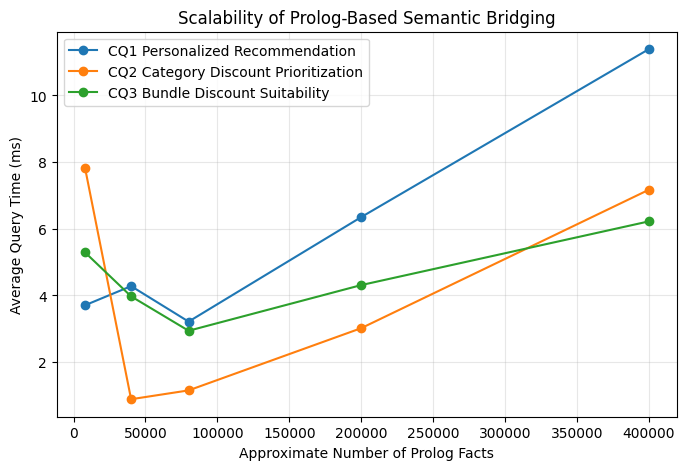

In [28]:
# Plot query time growth as the synthetic knowledge base increases.
plt.figure(figsize=(8, 5))

plt.plot(
    scalability_summary_df["Approx. Facts"],
    scalability_summary_df["CQ1 Time (ms)"],
    marker="o",
    label="CQ1 Personalized Recommendation",
)
plt.plot(
    scalability_summary_df["Approx. Facts"],
    scalability_summary_df["CQ2 Time (ms)"],
    marker="o",
    label="CQ2 Category Discount Prioritization",
)
plt.plot(
    scalability_summary_df["Approx. Facts"],
    scalability_summary_df["CQ3 Time (ms)"],
    marker="o",
    label="CQ3 Bundle Discount Suitability",
)

plt.xlabel("Approximate Number of Prolog Facts")
plt.ylabel("Average Query Time (ms)")
plt.title("Scalability of Prolog-Based Semantic Bridging")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [29]:
# Export benchmark results for use in the paper.
output_csv = "scalability_results.csv"
scalability_summary_df.to_csv(output_csv, index=False)
print(f"Saved scalability results to {output_csv}")


Saved scalability results to scalability_results.csv


### Interpreting the Results

Use the resulting table and plot to discuss whether the inference time grows smoothly as the number of Prolog facts increases.
A useful paper-level interpretation is to compare the three CQs:

- CQ1 is expected to be efficient because it is anchored in the target user's purchases and direct product relations.
- CQ2 may grow more noticeably because it uses aggregate counts over purchases and also-buy targets.
- CQ3 may be sensitive to the number of product-product relations, since bundle candidates are inferred from pairwise relations.

The goal is not to prove asymptotic complexity, but to provide empirical evidence that the Semantic Bridging engine remains operationally viable under progressively larger formal knowledge bases.
